### Part II

Now that you have written several moderately complicated queries, you have been asked to generate some plots/charts using Python/Pandas/Matplotlib/Seaborn to visualize some of the data and perform a linear regression. To do this, you will need to extract the data from the database using SQL and put it into a Pandas data frame. I recommend you look at SQLAlchemy and the MySQL Python Connector to make the connection to the database running on your local machine. Then you can generate the required plots and analysis according to the specifications below. Ensure all plots have tles and axes are correctly labeled/styled.

In [2]:
# imports 
import mysql.connector

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# MySQL Connection
mydb = mysql.connector.connect(
    host="localhost",
    user="root",
    password="samsung@777", # change MySQL password to the MySQL password of whoever is using this Python script
    database="sakila"
)

In [4]:
# checking if database is connected (ensure sakila database is running on MySQL while this Python script is running)
if mydb.is_connected():
    print("Connected to Sakila database")

Connected to Sakila database


In [5]:
# checking if output correctly displays
query = "SELECT * FROM customer" # run same query line in MySQL to verify result
df = pd.read_sql(query, mydb)

In [6]:
df # results match. Successfully connected!

,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36,2006-02-15 04:57:20
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36,2006-02-15 04:57:20
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36,2006-02-15 04:57:20
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36,2006-02-15 04:57:20
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36,2006-02-15 04:57:20
...,...,...,...,...,...,...,...,...,...
594,595,1,TERRENCE,GUNDERSON,TERRENCE.GUNDERSON@sakilacustomer.org,601,1,2006-02-14 22:04:37,2006-02-15 04:57:20
595,596,1,ENRIQUE,FORSYTHE,ENRIQUE.FORSYTHE@sakilacustomer.org,602,1,2006-02-14 22:04:37,2006-02-15 04:57:20
596,597,1,FREDDIE,DUGGAN,FREDDIE.DUGGAN@sakilacustomer.org,603,1,2006-02-14 22:04:37,2006-02-15 04:57:20
597,598,1,WADE,DELVALLE,WADE.DELVALLE@sakilacustomer.org,604,1,2006-02-14 22:04:37,2006-02-15 04:57:20


1) Create a horizontal bar chart that shows all the film categories and how many films fall in that
category. The bar chart should be sorted so the largest film category is at the top and the
smallest is at the bottom.

In [7]:
query_1 = """
SELECT name as category, count(film.film_id) as num_films
FROM film_category JOIN film ON film_category.film_id = film.film_id JOIN category ON film_category.category_id = category.category_id
GROUP BY name
ORDER BY name ASC;
"""

df_1 = pd.read_sql(query_1, mydb)
df_1

,category,num_films
0,Action,64
1,Animation,66
2,Children,60
3,Classics,57
4,Comedy,58
5,Documentary,68
6,Drama,62
7,Family,69
8,Foreign,73
9,Games,61


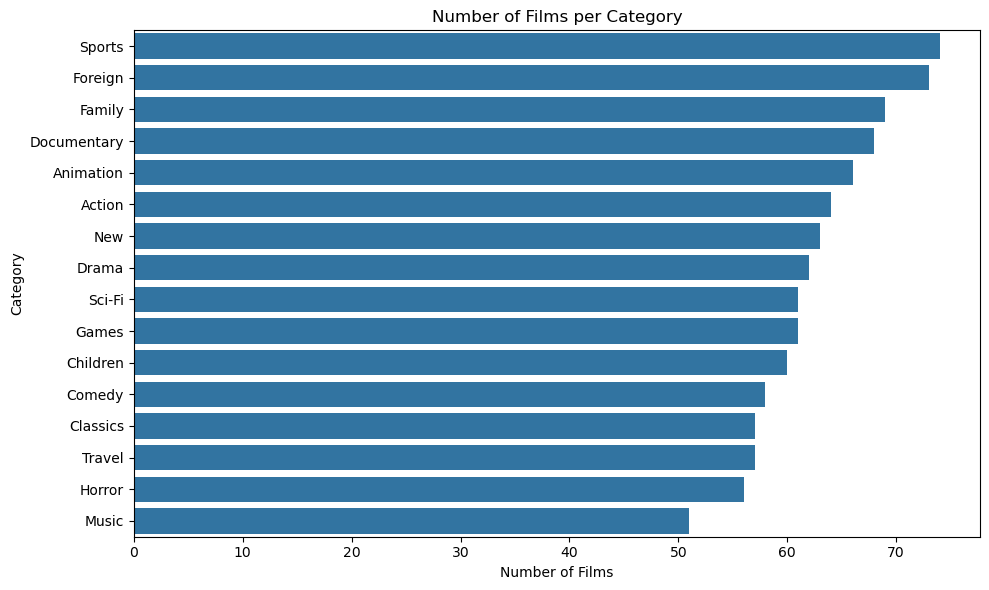

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_1.sort_values(by="num_films", ascending=False),
    x="num_films",
    y="category",
    orient="h"
)

plt.title("Number of Films per Category")
plt.xlabel("Number of Films")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

2) Create a horizontal bar chart that shows the top ten countries by city count. The bar chart should be sorted so the country with the largest number of cities is at the top and the country with the smallest number of cities is at the bottom.

In [9]:
query_2 = """
SELECT country, COUNT(city) as num_cities
FROM country JOIN city ON country.country_id = city.country_id
GROUP BY country
ORDER BY country ASC;
"""

df_2 = pd.read_sql(query_2, mydb)
df_2

,country,num_cities
0,Afghanistan,1
1,Algeria,3
2,American Samoa,1
3,Angola,2
4,Anguilla,1
...,...,...
104,Vietnam,6
105,"Virgin Islands, U.S.",1
106,Yemen,4
107,Yugoslavia,2


In [10]:
df_2.sort_values(by="num_cities", ascending=False).head(10)

,country,num_cities
43,India,60
22,China,53
102,United States,35
49,Japan,31
59,Mexico,30
79,Russian Federation,28
14,Brazil,28
74,Philippines,20
96,Turkey,15
44,Indonesia,14


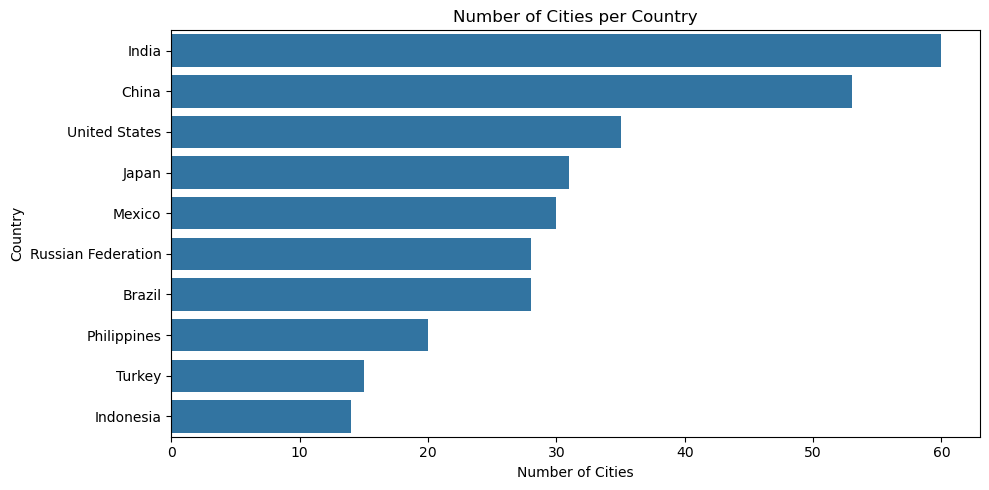

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_2.sort_values(by="num_cities", ascending=False).head(10),
    x="num_cities",
    y="country",
    orient="h"
)

plt.title("Number of Cities per Country")
plt.xlabel("Number of Cities")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

3) Create a horizontal bar chart that shows the top ten films by actor count. The bar chart should be sorted so the film with the largest number of actors is at the top and the film with the smallest number of actors is at the bottom.

In [12]:
query_3 = """
SELECT title, COUNT(actor.actor_id) as num_actors
FROM actor JOIN film_actor ON actor.actor_id = film_actor.actor_id JOIN film ON film_actor.film_id = film.film_id
GROUP BY title, film.film_id
ORDER BY title ASC;
"""

df_3 = pd.read_sql(query_3, mydb)
df_3

,title,num_actors
0,ACADEMY DINOSAUR,10
1,ACE GOLDFINGER,4
2,ADAPTATION HOLES,5
3,AFFAIR PREJUDICE,5
4,AFRICAN EGG,5
...,...,...
992,YOUNG LANGUAGE,5
993,YOUTH KICK,5
994,ZHIVAGO CORE,6
995,ZOOLANDER FICTION,5


In [13]:
df_3.sort_values(by="num_actors", ascending=False).head(10)

,title,num_actors
505,LAMBS CINCINATTI,15
711,RANDOM GO,13
603,MUMMY CREATURES,13
86,BOONDOCK BALLROOM,13
145,CHITTY LOCK,13
248,DRACULA CRYSTAL,13
187,CRAZY HOME,13
526,LONELY ELEPHANT,12
888,TITANIC BOONDOCK,12
33,ARABIA DOGMA,12


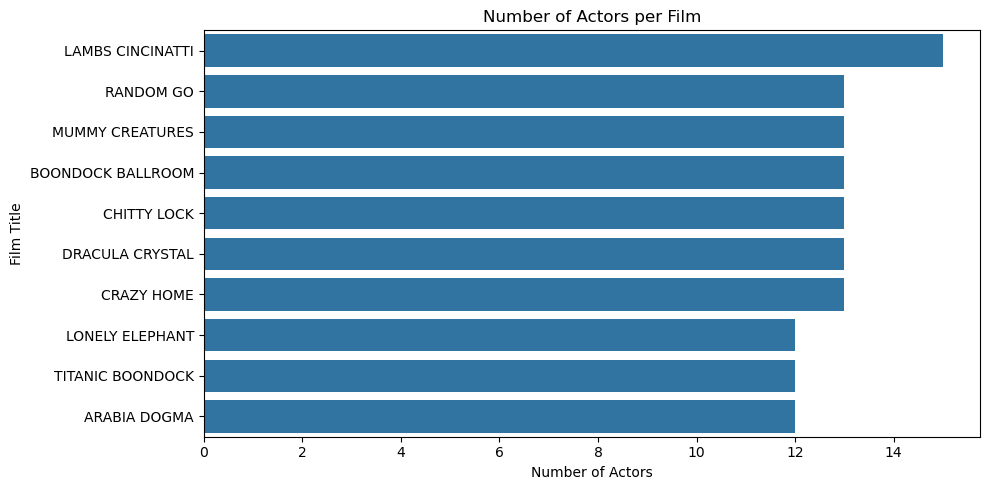

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_3.sort_values(by="num_actors", ascending=False).head(10),
    x="num_actors",
    y="title",
    orient="h"
)

plt.title("Number of Actors per Film")
plt.xlabel("Number of Actors")
plt.ylabel("Film Title")

plt.tight_layout()
plt.show()

4) Create a horizontal bar chart that shows the top ten countries by total number of rentals. The bar chart should be sorted so the country with the largest number of rentals is at the top and the country with the smallest number of rentals is at the bottom.

In [15]:
#Rentals belong to customers
#Customers live at an address
#Address inside city
# City inside country

query_4 = """
SELECT country.country, COUNT(rental.rental_id) as num_rentals
FROM rental JOIN customer ON rental.customer_id = customer.customer_id 
JOIN address ON customer.address_id = address.address_id 
JOIN city ON address.city_id = city.city_id 
JOIN country ON city.country_id = country.country_id
GROUP BY country.country
ORDER BY num_rentals DESC;
"""

df_4 = pd.read_sql(query_4, mydb)
df_4

,country,num_rentals
0,India,1572
1,China,1426
2,United States,968
3,Japan,825
4,Mexico,796
...,...,...
103,Madagascar,22
104,Nepal,22
105,American Samoa,20
106,Afghanistan,18


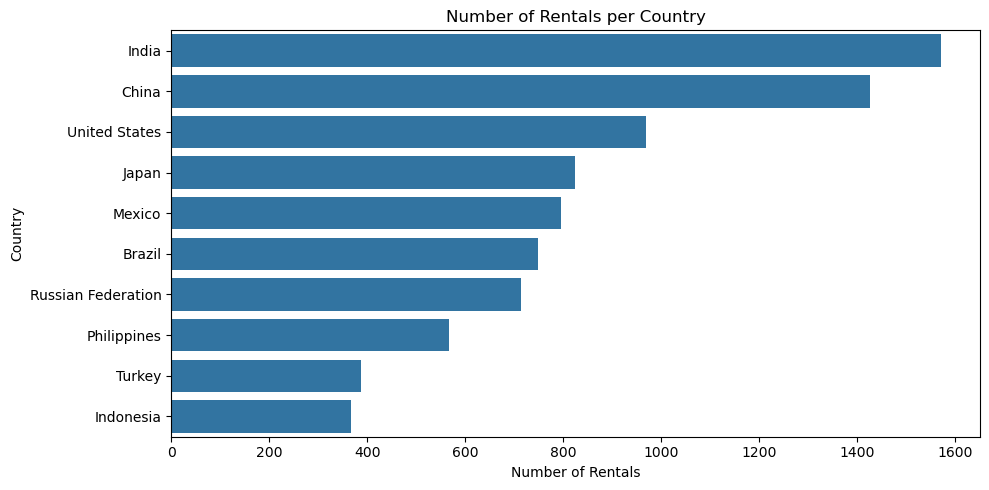

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_4.sort_values(by="num_rentals", ascending=False).head(10),
    x="num_rentals",
    y="country",
    orient="h"
)

plt.title("Number of Rentals per Country")
plt.xlabel("Number of Rentals")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

5) Create a horizontal bar chart that shows the top ten countries by total amount of money spent. The bar chart should be sorted so the country with the largest amount of money spent is at the top and the country with the smallest amount of money spent is at the bottom.

In [17]:
# payments for each rental
# rentals purchased by each customer
# customer lives in an address
# address in a city
# cities in a country

query_5 = """
SELECT country, SUM(amount) AS total_spent
FROM payment
JOIN rental ON payment.rental_id = rental.rental_id
JOIN customer ON rental.customer_id = customer.customer_id
JOIN address ON customer.address_id = address.address_id
JOIN city ON address.city_id = city.city_id
JOIN country ON city.country_id = country.country_id
GROUP BY country
ORDER BY total_spent DESC;
"""

# Load data into DataFrame
df_5 = pd.read_sql(query_5, mydb)
df_5

,country,total_spent
0,India,6628.28
1,China,5798.74
2,United States,4110.32
3,Japan,3470.75
4,Mexico,3307.04
...,...,...
103,Tunisia,78.77
104,Tonga,73.82
105,Lithuania,73.76
106,American Samoa,71.80


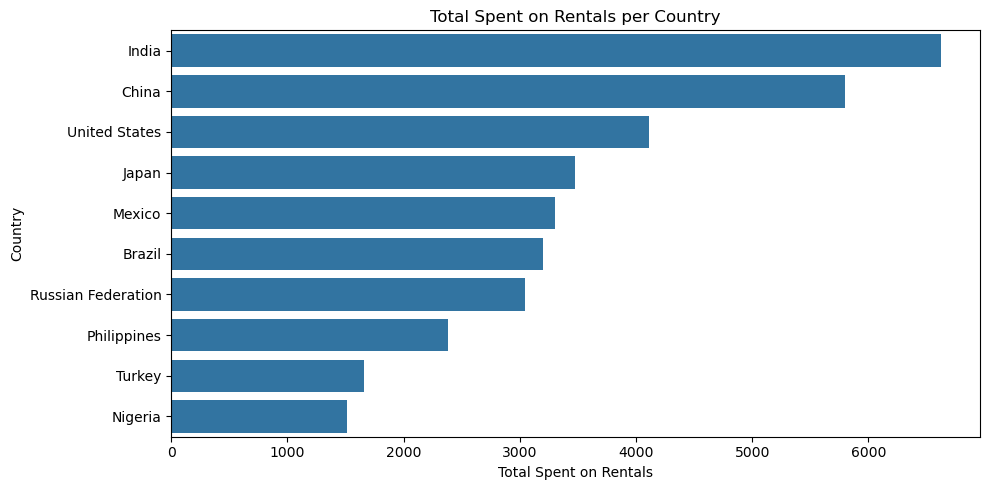

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_5.sort_values(by="total_spent", ascending=False).head(10),
    x="total_spent",
    y="country",
    orient="h"
)

plt.title("Total Spent on Rentals per Country")
plt.xlabel("Total Spent on Rentals")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

6) Create a scatter plot comparing the number of rentals on the X axis and the amount of money spent on the Y axis.

In [19]:
# Query to get number of rentals and total money spent per country
query_6 = """
SELECT country, COUNT(rental.rental_id) AS num_rentals, SUM(payment.amount) AS total_spent
FROM rental
JOIN payment ON rental.rental_id = payment.rental_id
JOIN customer ON rental.customer_id = customer.customer_id
JOIN address ON customer.address_id = address.address_id
JOIN city ON address.city_id = city.city_id
JOIN country ON city.country_id = country.country_id
GROUP BY country
ORDER BY total_spent DESC;
"""

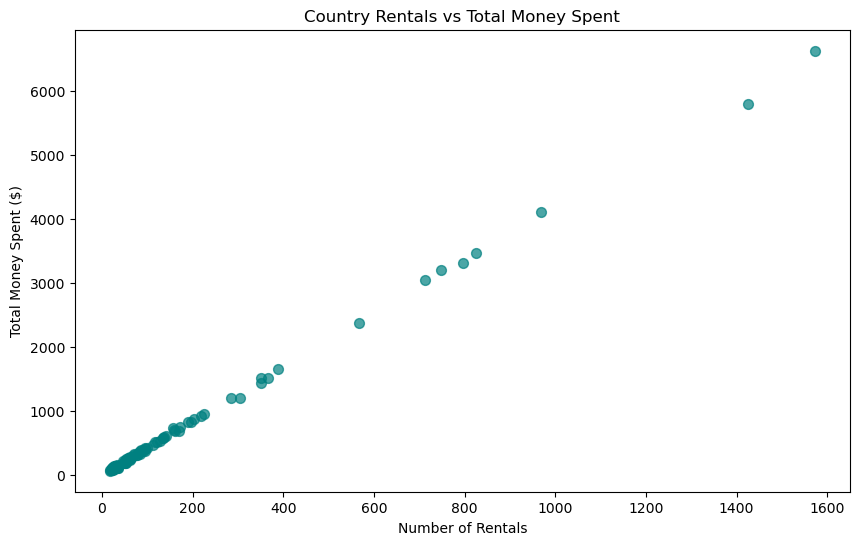

In [20]:
# Load data into DataFrame
df_6 = pd.read_sql(query_6, mydb)

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_6['num_rentals'], df_6['total_spent'], color='teal', s=50, alpha=0.7)
plt.xlabel('Number of Rentals')
plt.ylabel('Total Money Spent ($)')
plt.title('Country Rentals vs Total Money Spent')

plt.show()

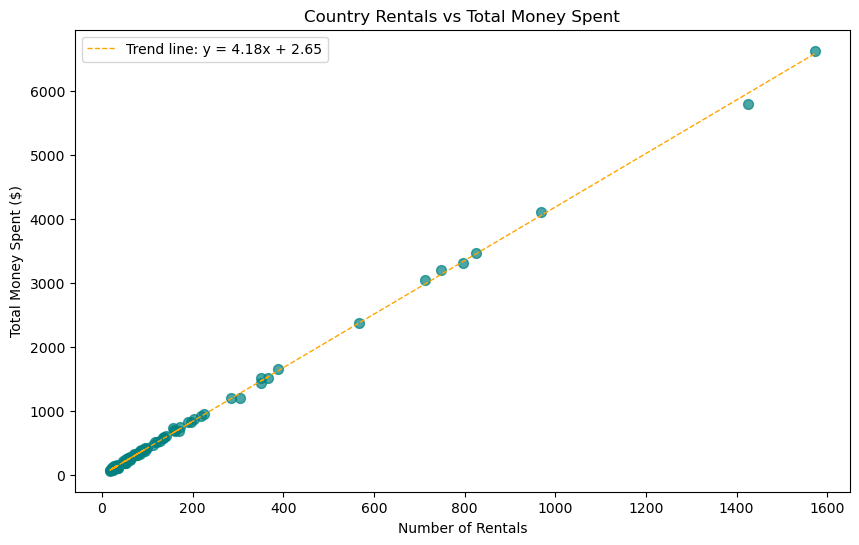

In [21]:
# Load data into DataFrame
df_6 = pd.read_sql(query_6, mydb)

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_6['num_rentals'], df_6['total_spent'], color='teal', s=50, alpha=0.7)
plt.xlabel('Number of Rentals')
plt.ylabel('Total Money Spent ($)')
plt.title('Country Rentals vs Total Money Spent')

# Calculate trend line
x = df_6['num_rentals']
y = df_6['total_spent']
m, b = np.polyfit(x, y, 1)  # Linear fit: y = m*x + b

# Plot trend line
plt.plot(x, m*x + b, color='orange', linestyle='--', linewidth=1, label=f'Trend line: y = {m:.2f}x + {b:.2f}')
plt.legend()

plt.show()

Finally, perform a statistical linear regression (not for prediction) with the number of rentals as the independent variable and the amount of money spent as the dependent variable. Report your results and your conclusions.

In [22]:
# import relavent libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

In [39]:
query_reg_country = """
SELECT country, COUNT(rental.rental_id) AS num_rentals, SUM(payment.amount) AS total_spent
FROM rental
JOIN payment ON rental.rental_id = payment.rental_id
JOIN customer ON rental.customer_id = customer.customer_id
JOIN address ON customer.address_id = address.address_id
JOIN city ON address.city_id = city.city_id
JOIN country ON city.country_id = country.country_id
GROUP BY country
ORDER BY total_spent DESC;
"""

df_country = pd.read_sql(query_reg_country, mydb)
df_country

,country,num_rentals,total_spent
0,India,1572,6628.28
1,China,1426,5798.74
2,United States,968,4110.32
3,Japan,825,3470.75
4,Mexico,796,3307.04
...,...,...,...
103,Tunisia,23,78.77
104,Tonga,18,73.82
105,Lithuania,24,73.76
106,American Samoa,20,71.80


In [40]:
# Establishing the variables for the regression
X = df_country[["num_rentals"]]   # independent variable
y = df_country["total_spent"]     # dependent variable

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit simple regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make prediction
y_pred = model.predict(X_test)

In [41]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Slope (coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Slope (coefficient): 4.177910651439456
Intercept: 4.250067731408876
Mean Squared Error: 678.5015839153083
R-squared: 0.9996842721318164


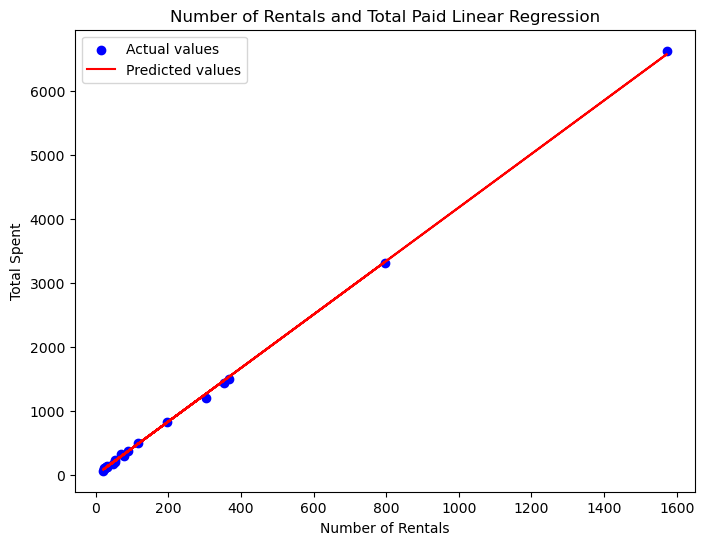

In [42]:
#Graphing actual values on the predicted line. 
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual values")
plt.plot(X_test, y_pred, color="red", label="Predicted values")
plt.xlabel("Number of Rentals")
plt.ylabel("Total Spent")
plt.title("Number of Rentals and Total Paid Linear Regression")
plt.legend()
plt.show()

From this simple regression, the model easily predicts Total Spent from the number of rentals. While an R2 score of .99 would normally be suspicious in a more complex model, it is fair to assume the high score comes from the predictable relationship of more rentals costing more money. Another reason for the high adjusted r square value may be due to the small number of observations (countries) present in the dataset.